In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check GPU availability
print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✓ GPU Available: {gpus[0].name}")
    print("✓ Training will be FAST!")
else:
    print("⚠ No GPU detected - Training will be slower")
    print("  Go to: Runtime → Change runtime type → GPU")


TensorFlow Version: 2.19.0
✓ GPU Available: /physical_device:GPU:0
✓ Training will be FAST!



STEP 1: Loading CIFAR-10 Dataset
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training samples: 50000
Test samples: 10000
Image shape: (32, 32, 3)
Number of classes: 10


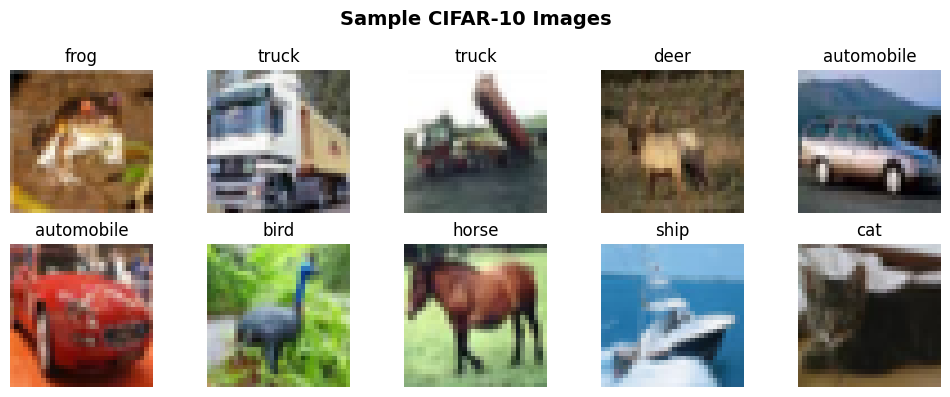

In [2]:
print("\n" + "="*70)
print("STEP 1: Loading CIFAR-10 Dataset")
print("="*70)

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")
print(f"Image shape: {x_train.shape[1:]}")
print(f"Number of classes: {len(np.unique(y_train))}")

# Visualize sample images
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
print("\n" + "="*70)
print("STEP 2: Defining CNN Architectures")
print("="*70)


STEP 2: Defining CNN Architectures


In [4]:
def model_baseline():
    """Baseline: No BN, No Dropout"""
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def model_with_bn_dropout():
    """With Batch Normalization AND Dropout"""
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Flatten(),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [5]:
def model_shallow():
    """Shallow Network: 2 Conv Layers"""
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def model_deep():
    """Deep Network: 4 Conv Layers"""
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [6]:
def model_leaky_relu():
    """Model with Leaky ReLU"""
    model = models.Sequential([
        layers.Conv2D(32, 3, padding='same', input_shape=(32,32,3)),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, padding='same'),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, padding='same'),
        layers.LeakyReLU(alpha=0.1),
        layers.Flatten(),

        layers.Dense(64),
        layers.LeakyReLU(alpha=0.1),
        layers.Dense(10, activation='softmax')
    ])
    return model

def model_tanh():
    """Model with Tanh activation"""
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='tanh', padding='same', input_shape=(32,32,3)),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='tanh', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='tanh', padding='same'),
        layers.Flatten(),
        layers.Dense(64, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])
    return model

print("✓ All model architectures defined")

✓ All model architectures defined


In [7]:
def train_model(model, name, epochs=12):
    """Train and evaluate a model"""
    print(f"\nTraining: {name}")
    print("-" * 70)

    # Compile
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train with progress bar
    history = model.fit(x_train, y_train,
                       epochs=epochs,
                       batch_size=64,
                       validation_split=0.2,
                       verbose=1)  # Show progress bar in Colab

    # Evaluate
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    print(f"✓ Test Accuracy: {test_acc:.4f}")
    print(f"✓ Test Loss: {test_loss:.4f}")

    return {
        'name': name,
        'history': history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'train_acc': history.history['accuracy'][-1],
        'val_acc': history.history['val_accuracy'][-1]
    }

In [8]:
print("\n" + "="*70)
print("STEP 3: Training All Models")
print("="*70)

# Dictionary to store all results
all_results = {}

# EXPERIMENT 1: BN and Dropout
print("\n>>> EXPERIMENT 1: Batch Normalization and Dropout")
all_results['Baseline (No BN/Dropout)'] = train_model(model_baseline(), 'Baseline')
all_results['With BN + Dropout'] = train_model(model_with_bn_dropout(), 'BN + Dropout')

# EXPERIMENT 2: Network Depth
print("\n>>> EXPERIMENT 2: Network Depth")
all_results['Shallow (2 Conv)'] = train_model(model_shallow(), 'Shallow')
all_results['Deep (4 Conv)'] = train_model(model_deep(), 'Deep')

# EXPERIMENT 3: Activation Functions
print("\n>>> EXPERIMENT 3: Activation Functions")
all_results['ReLU (Baseline)'] = all_results['Baseline (No BN/Dropout)']  # Reuse
all_results['Leaky ReLU'] = train_model(model_leaky_relu(), 'Leaky ReLU')
all_results['Tanh'] = train_model(model_tanh(), 'Tanh')


STEP 3: Training All Models

>>> EXPERIMENT 1: Batch Normalization and Dropout

Training: Baseline
----------------------------------------------------------------------
Epoch 1/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.3421 - loss: 1.7947 - val_accuracy: 0.5551 - val_loss: 1.2604
Epoch 2/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5695 - loss: 1.2005 - val_accuracy: 0.6270 - val_loss: 1.0651
Epoch 3/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6426 - loss: 1.0054 - val_accuracy: 0.6579 - val_loss: 0.9861
Epoch 4/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6865 - loss: 0.8882 - val_accuracy: 0.6789 - val_loss: 0.9425
Epoch 5/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7195 - loss: 0.7943 - val_accuracy: 0.6797 - val_loss: 0.9543
Epoch 6/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7473 - loss: 0.7184 - val_accuracy: 0.6919 - val_loss: 0.9351
Epoch 7/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accurac


STEP 4: Results Analysis

Results Summary:
                   Model Test Accuracy Test Loss Train Accuracy Val Accuracy
Baseline (No BN/Dropout)        0.6712    1.2443         0.8493       0.6708
       With BN + Dropout        0.6623    1.0187         0.7815       0.6659
        Shallow (2 Conv)        0.6523    1.2345         0.8415       0.6570
           Deep (4 Conv)        0.6899    1.6012         0.9412       0.7026
         ReLU (Baseline)        0.6712    1.2443         0.8493       0.6708
              Leaky ReLU        0.6957    1.5122         0.9175       0.7026
                    Tanh        0.6469    1.1428         0.8087       0.6485


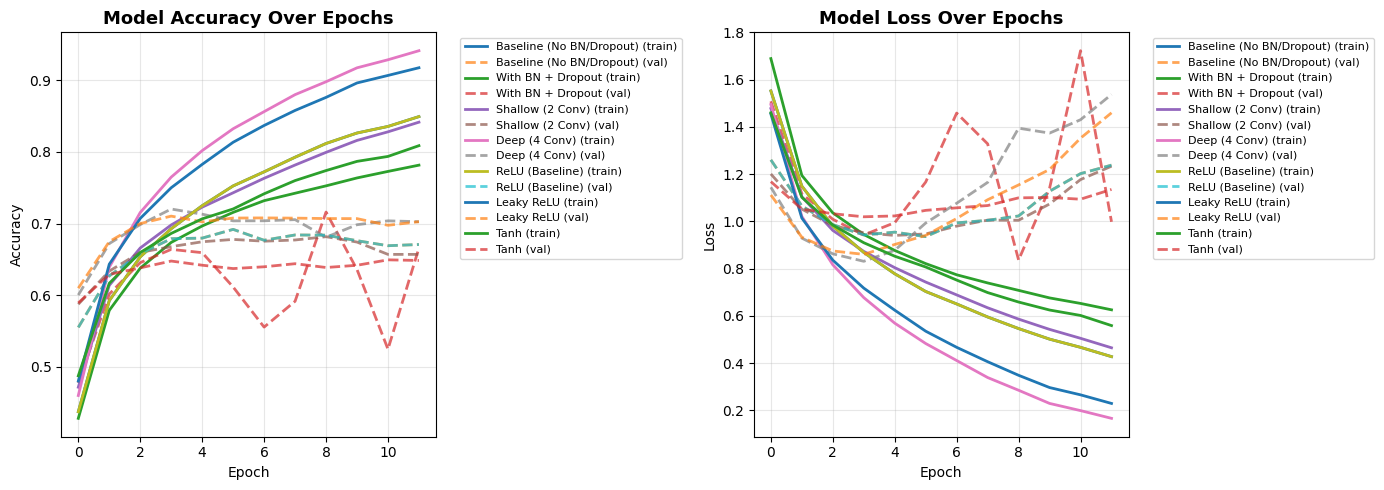

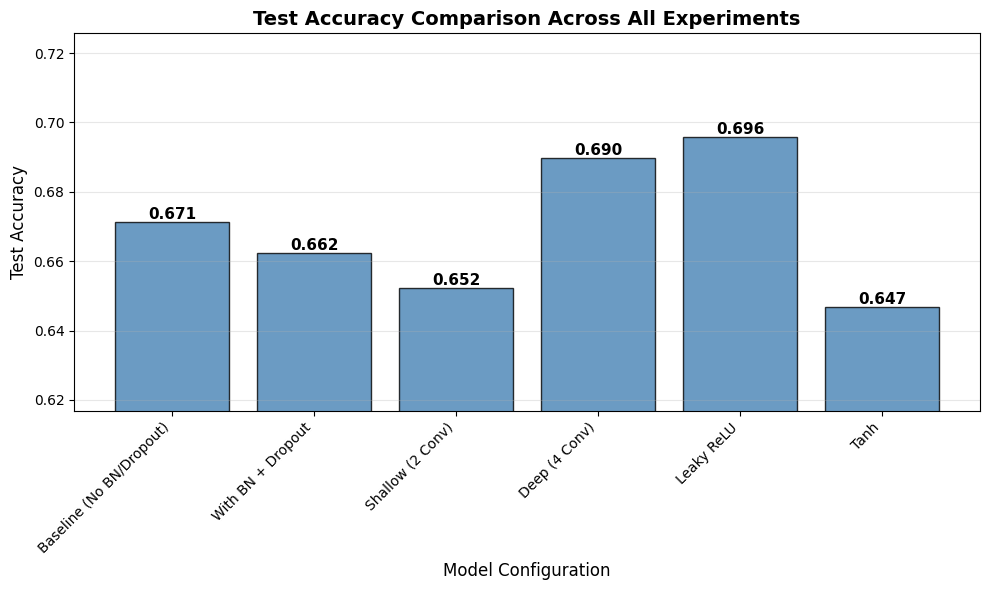

In [9]:
print("\n" + "="*70)
print("STEP 4: Results Analysis")
print("="*70)

# Create results summary table
results_data = []
for name, result in all_results.items():
    results_data.append({
        'Model': name,
        'Test Accuracy': f"{result['test_acc']:.4f}",
        'Test Loss': f"{result['test_loss']:.4f}",
        'Train Accuracy': f"{result['train_acc']:.4f}",
        'Val Accuracy': f"{result['val_acc']:.4f}"
    })

results_df = pd.DataFrame(results_data)
print("\nResults Summary:")
print(results_df.to_string(index=False))

# Plot 1: Training History Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, result in all_results.items():
    history = result['history']
    axes[0].plot(history.history['accuracy'], label=f'{name} (train)', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label=f'{name} (val)',
                linestyle='--', linewidth=2, alpha=0.7)

axes[0].set_title('Model Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

for name, result in all_results.items():
    history = result['history']
    axes[1].plot(history.history['loss'], label=f'{name} (train)', linewidth=2)
    axes[1].plot(history.history['val_loss'], label=f'{name} (val)',
                linestyle='--', linewidth=2, alpha=0.7)

axes[1].set_title('Model Loss Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: Test Accuracy Comparison
names = [r['name'] for r in all_results.values()]
test_accs = [r['test_acc'] for r in all_results.values()]

# Remove duplicates for cleaner visualization
unique_results = {}
for name, result in all_results.items():
    if name not in ['ReLU (Baseline)']:  # Skip duplicate
        unique_results[name] = result

names = list(unique_results.keys())
test_accs = [unique_results[name]['test_acc'] for name in names]

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(names)), test_accs, color='steelblue', alpha=0.8, edgecolor='black')

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Model Configuration', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Test Accuracy Comparison Across All Experiments',
         fontsize=14, fontweight='bold')
plt.xticks(range(len(names)), names, rotation=45, ha='right')
plt.ylim([min(test_accs)-0.03, max(test_accs)+0.03])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
print("\n" + "="*70)
print("DETAILED ANALYSIS BY EXPERIMENT")
print("="*70)

# Experiment 1 Analysis
print("\n1. BATCH NORMALIZATION & DROPOUT:")
bn_baseline = all_results['Baseline (No BN/Dropout)']['test_acc']
bn_with = all_results['With BN + Dropout']['test_acc']
improvement = (bn_with - bn_baseline) * 100
print(f"   Baseline: {bn_baseline:.4f}")
print(f"   With BN+Dropout: {bn_with:.4f}")
print(f"   Improvement: {improvement:+.2f}%")

# Experiment 2 Analysis
print("\n2. NETWORK DEPTH:")
shallow_acc = all_results['Shallow (2 Conv)']['test_acc']
deep_acc = all_results['Deep (4 Conv)']['test_acc']
depth_diff = (deep_acc - shallow_acc) * 100
print(f"   Shallow (2 Conv): {shallow_acc:.4f}")
print(f"   Deep (4 Conv): {deep_acc:.4f}")
print(f"   Difference: {depth_diff:+.2f}%")

# Experiment 3 Analysis
print("\n3. ACTIVATION FUNCTIONS:")
relu_acc = all_results['Baseline (No BN/Dropout)']['test_acc']
leaky_acc = all_results['Leaky ReLU']['test_acc']
tanh_acc = all_results['Tanh']['test_acc']
print(f"   ReLU: {relu_acc:.4f}")
print(f"   Leaky ReLU: {leaky_acc:.4f}")
print(f"   Tanh: {tanh_acc:.4f}")

# Best Model
best_model = max(all_results.items(), key=lambda x: x[1]['test_acc'])
print("\n" + "="*70)
print(f"BEST MODEL: {best_model[0]}")
print(f"Test Accuracy: {best_model[1]['test_acc']:.4f}")
print("="*70)


DETAILED ANALYSIS BY EXPERIMENT

1. BATCH NORMALIZATION & DROPOUT:
   Baseline: 0.6712
   With BN+Dropout: 0.6623
   Improvement: -0.89%

2. NETWORK DEPTH:
   Shallow (2 Conv): 0.6523
   Deep (4 Conv): 0.6899
   Difference: +3.76%

3. ACTIVATION FUNCTIONS:
   ReLU: 0.6712
   Leaky ReLU: 0.6957
   Tanh: 0.6469

BEST MODEL: Leaky ReLU
Test Accuracy: 0.6957


In [11]:
print("\n" + "="*70)
print("KEY OBSERVATIONS")
print("="*70)
print("""
1. Batch Normalization & Dropout:
   - BN helps stabilize training and speeds up convergence
   - Dropout prevents overfitting by randomly dropping units
   - Combined effect typically reduces overfitting gap

2. Network Depth:
   - Deeper networks can learn more complex features
   - But may require more data and training time
   - Risk of overfitting if too deep without regularization

3. Activation Functions:
   - ReLU and Leaky ReLU generally perform better than Tanh
   - Leaky ReLU helps avoid "dying ReLU" problem
   - Tanh can suffer from vanishing gradients in deep networks
""")


KEY OBSERVATIONS

1. Batch Normalization & Dropout:
   - BN helps stabilize training and speeds up convergence
   - Dropout prevents overfitting by randomly dropping units
   - Combined effect typically reduces overfitting gap

2. Network Depth:
   - Deeper networks can learn more complex features
   - But may require more data and training time
   - Risk of overfitting if too deep without regularization

3. Activation Functions:
   - ReLU and Leaky ReLU generally perform better than Tanh
   - Leaky ReLU helps avoid "dying ReLU" problem
   - Tanh can suffer from vanishing gradients in deep networks

